# 04 · The Arena

All six detectors on the same planted-truth dataset, scored two ways.

1. **Detection quality** — precision and recall against the known labels. (Never *accuracy*: at 8% contamination a detector that flags nothing is already 92% "accurate".)
2. **Agreement** — how often the detectors actually concur on *which* points are outliers. This is the headline: among the points flagged by anyone, only about **one in five** is flagged by all six.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

_root = Path.cwd()
while _root != _root.parent and not (_root / "pyproject.toml").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.artifacts import save_figure, save_json

plt.rcParams["figure.dpi"] = 110
SEED = 7

from src.datasets.synthetic import make_dataset
from src.evaluation.comparison import run_arena
from src.evaluation.detection import detection_scores
from src.visualisation import agreement_heatmap, scatter_flags

res = run_arena(n_samples=1000, n_features=2, contamination=0.08, seed=SEED)
scores = res.scores.round(3)
agreement = res.agreement
# Recreate the identical dataset (deterministic) to plot the disputed points.
data = make_dataset(n_samples=1000, n_features=2, contamination=0.08, seed=SEED)

## 1 · Detection quality (precision & recall, not accuracy)

                  precision  recall     f1
detector                                  
three_sigma           1.000   0.338  0.505
iqr                   1.000   0.338  0.505
mahalanobis           0.750   0.750  0.750
isolation_forest      0.888   0.888  0.888
lof                   0.812   0.812  0.812
one_class_svm         0.709   0.700  0.704

A detector that flags NOTHING has accuracy 92.0% but recall 0% — which is why we report recall.


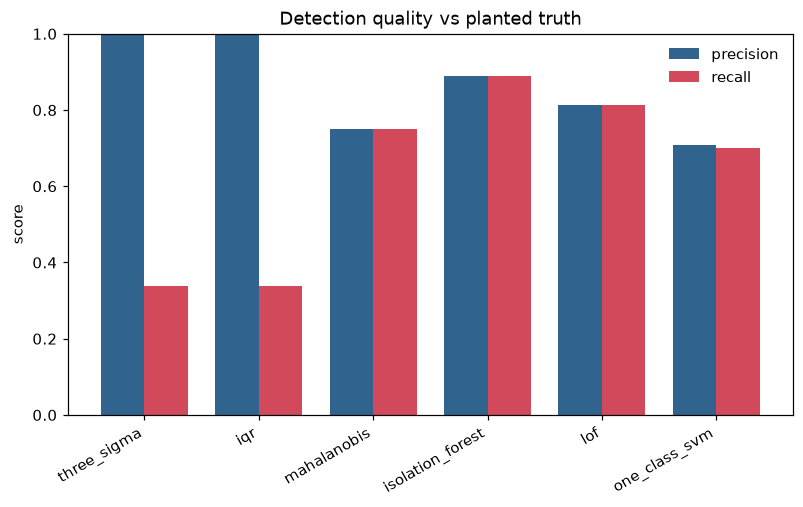

In [2]:
print(scores[["precision", "recall", "f1"]])

idx = np.arange(len(scores))
width = 0.38
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(idx - width / 2, scores["precision"], width, label="precision", color="#30638e")
ax.bar(idx + width / 2, scores["recall"], width, label="recall", color="#d1495b")
ax.set_xticks(idx, scores.index, rotation=30, ha="right")
ax.set(ylabel="score", ylim=(0, 1), title="Detection quality vs planted truth")
ax.legend(frameon=False)
save_figure(fig, "04_precision_recall")
save_json(scores, "04_scores")

# Why not accuracy: a do-nothing detector.
nothing = np.zeros(data.X.shape[0], dtype=bool)
do_nothing_accuracy = float(np.mean(nothing == data.y))
print(f"\nA detector that flags NOTHING has accuracy {do_nothing_accuracy:.1%} "
      f"but recall 0% — which is why we report recall.")

## 2 · Agreement — they concur on about a fifth

The matrix is the pairwise **Jaccard** overlap of the detectors' flagged sets: of the points either detector flags, the fraction both flag.

mean pairwise agreement (Jaccard) : 48.2%
consensus among flagged points    : 22.5%
disputed points (flagged by some, not all): 93


PosixPath('/workspaces/outlier_arena/outputs/data/04_agreement.json')

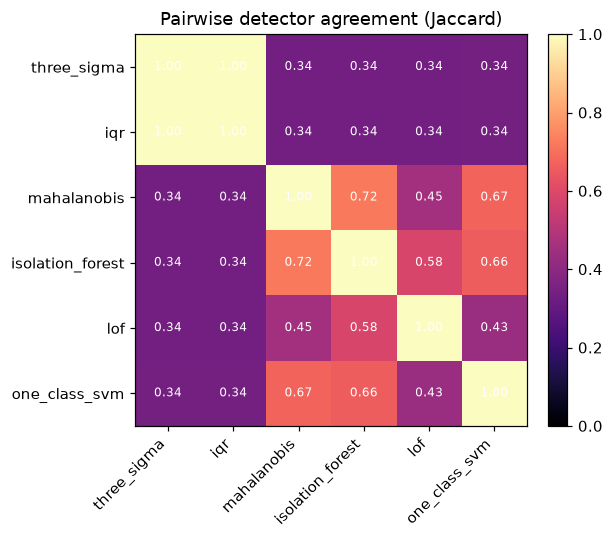

In [3]:
fig = agreement_heatmap(agreement.names, agreement.jaccard_matrix)
save_figure(fig, "04_agreement_matrix")

print(f"mean pairwise agreement (Jaccard) : {agreement.mean_agreement:.1%}")
print(f"consensus among flagged points    : {agreement.consensus_fraction:.1%}")
print(f"disputed points (flagged by some, not all): {agreement.n_disputed}")

save_json({
    "mean_pairwise_agreement": agreement.mean_agreement,
    "consensus_fraction_among_flagged": agreement.consensus_fraction,
    "n_disputed": agreement.n_disputed,
    "names": agreement.names,
    "jaccard_matrix": agreement.jaccard_matrix,
}, "04_agreement")

## 3 · The disputed points

These are the points at least one detector flags and at least one leaves alone. Your choice of detector silently decides whether each of them is removed from your dataset.

93 of 1000 points are disputed.


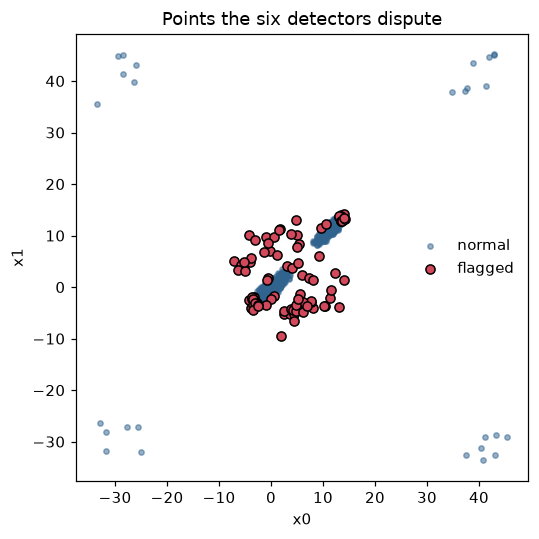

In [4]:
fig = scatter_flags(data.X, agreement.disputed, title="Points the six detectors dispute")
save_figure(fig, "04_disputed_points")
print(f"{agreement.n_disputed} of {data.X.shape[0]} points are disputed.")

## Takeaway

Your choice of detector silently determines which points get removed — and the detectors mostly do not agree on which those are. Run more than one and inspect the disagreements, rather than trusting a single verdict.

In [5]:
summary = {
    "notebook": "04_arena",
    "inputs": {"n_samples": 1000, "n_features": 2, "contamination": 0.08, "seed": SEED},
    "scores": scores.to_dict(orient="index"),
    "mean_pairwise_agreement": agreement.mean_agreement,
    "consensus_fraction_among_flagged": agreement.consensus_fraction,
    "n_disputed": agreement.n_disputed,
    "do_nothing_accuracy": do_nothing_accuracy,
    "claim": ("Among points flagged by any detector, only ~20% are flagged by all six; "
              "the detector choice decides which points are removed."),
}
save_json(summary, "04_summary")
summary

{'notebook': '04_arena',
 'inputs': {'n_samples': 1000,
  'n_features': 2,
  'contamination': 0.08,
  'seed': 7},
 'scores': {'three_sigma': {'precision': 1.0,
   'recall': 0.338,
   'f1': 0.505,
   'n_flagged': 27,
   'recall_global': 1.0,
   'recall_local': 0.0,
   'recall_multivariate': 0.0},
  'iqr': {'precision': 1.0,
   'recall': 0.338,
   'f1': 0.505,
   'n_flagged': 27,
   'recall_global': 1.0,
   'recall_local': 0.0,
   'recall_multivariate': 0.0},
  'mahalanobis': {'precision': 0.75,
   'recall': 0.75,
   'f1': 0.75,
   'n_flagged': 80,
   'recall_global': 1.0,
   'recall_local': 0.444,
   'recall_multivariate': 0.808},
  'isolation_forest': {'precision': 0.888,
   'recall': 0.888,
   'f1': 0.888,
   'n_flagged': 80,
   'recall_global': 1.0,
   'recall_local': 0.741,
   'recall_multivariate': 0.923},
  'lof': {'precision': 0.812,
   'recall': 0.812,
   'f1': 0.812,
   'n_flagged': 80,
   'recall_global': 1.0,
   'recall_local': 0.704,
   'recall_multivariate': 0.731},
  'one_